In [ ]:
#imports and uploading dataset

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_csv("canadadataset.csv", encoding ="latin1")

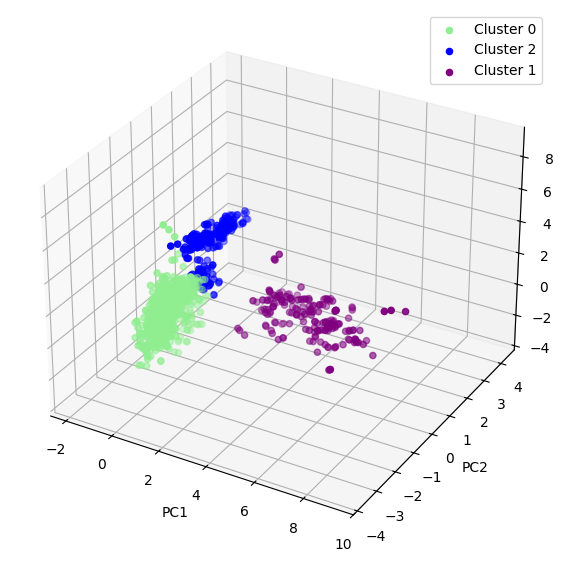

Explained Variance: [0.34541267 0.20867345 0.16006972]


In [ ]:
#preprocessing and pca and clustering

numerical_columns = [
    'Forecasted 90th Percentile Best Yield',
    'Forecasted Median Yield',
    '% Departure from the Long Term (1987-last year) Mean Yield',
    '% Departure from the Last 5 Years (2019-2023) Mean Yield',
    '% Departure from Last Year\'s Mean Yield',
    'Bravis-Pearson Coefficients of Determination (R2)',
    'Root Mean Square Error',
    'LATITUDE',
    'LONGITUDE'
]

def preprocess_data(data, numerical_columns):
  imputer = SimpleImputer(strategy='mean')
  imputed_data = imputer.fit_transform(data[numerical_columns])

  scale = StandardScaler()
  scaled_data = scale.fit_transform(imputed_data)

  return scaled_data

def apply_pca(data, n = 3):
  pca = PCA(n_components=n)
  pca_result = pca.fit_transform(data)
  pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2', 'PC3'])

  return pca_df, pca

def apply_kmeans(pca_data, n_clusters = 3):
  kmeans = KMeans(n_clusters=n_clusters, random_state = 42)
  pca_data['Cluster'] = kmeans.fit_predict(pca_data)

  return pca_data, kmeans

scaled_data = preprocess_data(df, numerical_columns)
pca_df, pca_model = apply_pca(scaled_data)
pca_df, kmeans_model = apply_kmeans(pca_df)

def plot_3d_clusters(pca_df):
  fig = plt.figure(figsize=(10, 7))
  ax = fig.add_subplot(111, projection='3d')

  colors = {0: "lightgreen", 1: "purple", 2: "blue"}

  for cluster in pca_df['Cluster'].unique():
    subset = pca_df[pca_df['Cluster'] == cluster]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], color=colors[cluster], label=f'Cluster {cluster}')

  ax.set_xlabel('PC1')
  ax.set_ylabel('PC2')
  ax.set_zlabel('PC3')
  ax.legend()

  plt.show()

plot_3d_clusters(pca_df)
print("Explained Variance:", pca_model.explained_variance_ratio_)

In [ ]:
pca_df, kmeans_model = apply_kmeans(pca_df)

def plot_cluster_map(df):
    import folium

    canada_center = [56.1304, -106.3468]
    m = folium.Map(location=canada_center, zoom_start=4, tiles="cartodb positron")

    cluster_colors = {0: 'lightgreen', 1: 'purple', 2: 'blue'}

    for idx, row in df.iterrows():
        folium.CircleMarker(
            location=[row['LATITUDE'], row['LONGITUDE']],
            radius=5,
            color=cluster_colors.get(row['Cluster'], 'black'),
            fill=True,
            fill_color=cluster_colors.get(row['Cluster'], 'black'),
            fill_opacity=0.8,
            popup=f"Cluster: {row['Cluster']}"
        ).add_to(m)

    print("Map created with", df['Cluster'].nunique(), "clusters")
    return m

df['Cluster'] = kmeans_model.labels_
map_plot = plot_cluster_map(df)
map_plot



Map created with 3 clusters


In [ ]:
def train_cluster_models(df):

    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
    from sklearn.preprocessing import StandardScaler
    from sklearn.impute import SimpleImputer
    from xgboost import XGBRegressor
    import numpy as np

    results = []

    for cluster in sorted(df['Cluster'].unique()):
        print(f"\nProcessing Cluster {cluster}")

        cluster_data = df[df['Cluster'] == cluster]

        X = cluster_data[['LONGITUDE', 'PC1', 'PC2', 'PC3']]
        y = cluster_data['Forecasted Median Yield']

        # Preprocessing
        X = SimpleImputer(strategy='mean').fit_transform(X)
        X = StandardScaler().fit_transform(X)

        # Split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Model
        model = XGBRegressor(random_state=42)
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = mean_absolute_percentage_error(y_test, y_pred) * 100

        print(f"RMSE: {rmse:.2f}")
        print(f"MAPE: {mape:.2f}%")

        results.append({
            "Cluster": cluster,
            "RMSE": rmse,
            "MAPE": mape
        })

    return pd.DataFrame(results)

df_model = df.copy()

df_model[['PC1', 'PC2', 'PC3']] = pca_df[['PC1', 'PC2', 'PC3']]
df_model['Cluster'] = pca_df['Cluster']

cluster_results = train_cluster_models(df_model)
print(cluster_results)


Processing Cluster 0
RMSE: 14.90
MAPE: 21.55%

Processing Cluster 1
RMSE: 106.21
MAPE: 7.36%

Processing Cluster 2
RMSE: 19.95
MAPE: 26.43%
   Cluster        RMSE       MAPE
0        0   14.904755  21.550675
1        1  106.212119   7.362127
2        2   19.947203  26.429175


In [ ]:
print(df_model.groupby('Cluster')['Forecasted Median Yield'].describe())

          count         mean         std     min     25%       50%        75%  \
Cluster                                                                         
0        1005.0    50.963622   20.944756   14.38   37.55    46.790    60.8000   
1         189.0  1153.103915  379.467604  483.11  803.32  1128.730  1480.1500   
2         274.0    69.403102   40.407732   16.39   46.53    57.795    70.5975   

             max  
Cluster           
0         145.77  
1        2006.02  
2         193.16  
